In [ ]:
import os
import re
import json
import math
import random
import zipfile
from pathlib import Path
from collections import Counter, defaultdict
import requests
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import torchvision
import torchvision.transforms as T


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device('cuda')
rare_threshold_ratio = 0.01
batch_size = 32
epochs_finetune = 8
epochs_scratch = 12
lr_finetune = 3e-4
lr_scratch = 1e-3
num_workers = 0
root = Path('data_dvm')
raw_dir = root / 'raw'
extract_dir = root / 'extracted'
raw_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)


In [4]:
import time
import shutil

file_id_quality_checked = 34792480
download_url = f"https://ndownloader.figshare.com/files/{file_id_quality_checked}"
zip_name = "dvm_quality_checked_front_view_images.zip"
zip_path = raw_dir / zip_name

extract_dir.mkdir(parents=True, exist_ok=True)

with requests.get(download_url, stream=True, timeout=120) as r:
    r.raise_for_status()
    total = int(r.headers.get("Content-Length", 0))
    print(f"Общий размер: {total / (1024*1024):.1f} MB")

    downloaded = 0
    start = time.time()
    chunk_size = 1024 * 1024
    last_logged_pct = -5

    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if not chunk:
                continue
            f.write(chunk)
            downloaded += len(chunk)

            pct = int(downloaded * 100 / total)
            if pct >= last_logged_pct + 5:
                elapsed = max(time.time() - start, 1e-6)
                speed = downloaded / elapsed / (1024 * 1024)
                print(
                    f"Загрузка: {pct}% "
                    f"({downloaded / (1024*1024):.1f}/{total / (1024*1024):.1f} MB), "
                    f"{speed:.2f} MB/s"
                )
                last_logged_pct = pct


Общий размер: 730.0 MB
Загрузка: 0% (1.0/730.0 MB), 1.73 MB/s
Загрузка: 5% (37.0/730.0 MB), 15.34 MB/s
Загрузка: 10% (73.0/730.0 MB), 17.23 MB/s
Загрузка: 15% (110.0/730.0 MB), 18.13 MB/s
Загрузка: 20% (146.0/730.0 MB), 18.52 MB/s
Загрузка: 25% (183.0/730.0 MB), 18.85 MB/s
Загрузка: 30% (219.0/730.0 MB), 19.11 MB/s
Загрузка: 35% (256.0/730.0 MB), 19.27 MB/s
Загрузка: 40% (292.0/730.0 MB), 19.34 MB/s
Загрузка: 45% (329.0/730.0 MB), 19.44 MB/s
Загрузка: 50% (365.0/730.0 MB), 19.51 MB/s
Загрузка: 55% (402.0/730.0 MB), 19.58 MB/s
Загрузка: 60% (438.0/730.0 MB), 19.65 MB/s
Загрузка: 65% (475.0/730.0 MB), 19.70 MB/s
Загрузка: 70% (511.0/730.0 MB), 19.72 MB/s
Загрузка: 75% (548.0/730.0 MB), 19.79 MB/s
Загрузка: 80% (584.0/730.0 MB), 19.80 MB/s
Загрузка: 85% (621.0/730.0 MB), 19.83 MB/s
Загрузка: 90% (657.0/730.0 MB), 19.87 MB/s
Загрузка: 95% (694.0/730.0 MB), 19.89 MB/s
Загрузка: 100% (730.0/730.0 MB), 19.91 MB/s


In [ ]:
extract_target = extract_dir / zip_path.stem
extract_target.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_target)


In [ ]:
image_exts = {'.jpg', '.jpeg', '.png'}
all_images = [p for p in extract_target.rglob('*') if p.suffix.lower() in image_exts]
if len(all_images) == 0:
    raise RuntimeError('No images found after extraction.')
def parse_color_from_path(img_path: Path):
    parent = img_path.parent.name
    tokens = parent.split('-')
    color = tokens[-1].strip().lower() if len(tokens) > 0 else 'unknown'
    color = color.replace('_', ' ')
    return color
records = []
for p in all_images:
    color = parse_color_from_path(p)
    records.append((str(p), color))
colors = [c for _, c in records]
count = Counter(colors)
total = len(colors)
min_count = max(1, int(total * rare_threshold_ratio))
processed = []
for img_path, color in records:
    if count[color] < min_count:
        processed.append((img_path, 'other'))
    else:
        processed.append((img_path, color))
label_names = sorted(list({c for _, c in processed}))
label_to_idx = {c: i for i, c in enumerate(label_names)}
idx_to_label = {i: c for c, i in label_to_idx.items()}
X = [p for p, _ in processed]
y = [label_to_idx[c] for _, c in processed]


In [ ]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=seed, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=seed, stratify=y_tmp
)
num_classes = len(label_names)


In [ ]:
from torch.utils.data import WeightedRandomSampler

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class CarColorDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        y = self.labels[idx]
        img = Image.open(p).convert('RGB')
        img = self.transform(img)
        return img, y

train_ds = CarColorDataset(X_train, y_train, train_tf)
val_ds = CarColorDataset(X_val, y_val, val_tf)
test_ds = CarColorDataset(X_test, y_test, val_tf)

cnt = Counter(y_train)
class_weights = {cls: 1.0 / cnt[cls] for cls in cnt}
sample_weights = np.array([class_weights[y] for y in y_train], dtype=np.float32)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=batch_size, sampler=sampler,
    num_workers=num_workers, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True
)


In [ ]:
# модели 1 и 2
def build_imagenet_model(num_classes):
    m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

class DinoColorHead(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(384, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        self.backbone.eval()
        with torch.no_grad():
            emb = self.backbone(x)
        emb = torch.nn.functional.normalize(emb, dim=1)
        return self.head(emb)

def build_non_imagenet_model(num_classes):
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    return DinoColorHead(backbone, num_classes)


In [ ]:
# модель 3
class ScratchColorCnn(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


In [ ]:
def eval_model(model, loader, criterion):
    model.eval()
    losses = []
    y_true = []
    y_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            pred = torch.argmax(logits, dim=1)
            y_true.extend(yb.cpu().numpy().tolist())
            y_pred.extend(pred.cpu().numpy().tolist())
    loss_mean = float(np.mean(losses))
    f1_macro = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    return {
        'loss': loss_mean,
        'f1_macro': f1_macro,
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
    }
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay=1e-4, freeze_backbone=False):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    if freeze_backbone:
        for n, p in model.named_parameters():
            if 'head' not in n and 'fc' not in n and 'classifier' not in n:
                p.requires_grad = False
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )
    best_state = None
    best_val_f1 = -1.0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': [],
    }
    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []
        y_true = []
        y_pred = []
        print(f'epoch {epoch}/{epochs}: start')
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            pred = torch.argmax(logits, dim=1)
            y_true.extend(yb.detach().cpu().numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())
            if i % 200 == 0:
                print(f'  batch {i}/{len(train_loader)}')
        train_loss = float(np.mean(batch_losses))
        train_f1 = f1_score(y_true, y_pred, average='macro')
        val_metrics = eval_model(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_metrics['f1_macro'])
        if val_metrics['f1_macro'] > best_val_f1:
            best_val_f1 = val_metrics['f1_macro']
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        print(
            f"epoch {epoch}/{epochs} done | "
            f"train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} | "
            f"train_f1={train_f1:.4f} val_f1={val_metrics['f1_macro']:.4f}"
        )
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [ ]:
# обучение модели 1
model_imagenet = build_imagenet_model(num_classes)
model_imagenet, hist_imagenet = train_model(
    model=model_imagenet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs_finetune,
    lr=lr_finetune,
    weight_decay=1e-4,
    freeze_backbone=False,
)


epoch 1/8: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 1/8 done | train_loss=1.7181 val_loss=1.6252 | train_f1=0.2611 val_f1=0.2969
epoch 2/8: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 2/8 done | train_loss=1.5032 val_loss=1.4951 | train_f1=0.3460 val_f1=0.3315
epoch 3/8: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 3/8 done | train_loss=1.3537 val_loss=1.4062 | train_f1=0.4260 val_f1=0.3839
epoch 4/8: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 4/8 done | train_loss=1.2211 val_loss=1.4126 | train_f1=0.4835 val_f1=0.4011
epoch 5/8: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batc

In [ ]:
# обучение модели 2
model_non_imagenet = build_non_imagenet_model(num_classes)
model_non_imagenet, hist_non_imagenet = train_model(
    model=model_non_imagenet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=12,
    lr=3e-3,
    weight_decay=1e-5,
    freeze_backbone=True,
)


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


epoch 1/12: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 1/12 done | train_loss=1.9226 val_loss=1.7897 | train_f1=0.2551 val_f1=0.2491
epoch 2/12: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 2/12 done | train_loss=1.7853 val_loss=1.7413 | train_f1=0.2995 val_f1=0.2836
epoch 3/12: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 3/12 done | train_loss=1.7139 val_loss=1.6859 | train_f1=0.3249 val_f1=0.2929
epoch 4/12: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 4/12 done | train_loss=1.6724 val_loss=1.6670 | train_f1=0.3387 val_f1=0.3074
epoch 5/12: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/13

In [ ]:
# обучение модели 3
model_scratch = ScratchColorCnn(num_classes)
model_scratch, hist_scratch = train_model(
    model=model_scratch,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    lr=1e-3,
    weight_decay=0.0,
    freeze_backbone=False,
)


epoch 1/20: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 1/20 done | train_loss=2.4245 val_loss=2.5253 | train_f1=0.1082 val_f1=0.0589
epoch 2/20: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 2/20 done | train_loss=2.2885 val_loss=2.1518 | train_f1=0.1398 val_f1=0.1476
epoch 3/20: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 3/20 done | train_loss=2.1624 val_loss=2.8222 | train_f1=0.1706 val_f1=0.0785
epoch 4/20: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/1353
  batch 1200/1353
epoch 4/20 done | train_loss=2.0816 val_loss=2.1929 | train_f1=0.1945 val_f1=0.0975
epoch 5/20: start
  batch 0/1353
  batch 200/1353
  batch 400/1353
  batch 600/1353
  batch 800/1353
  batch 1000/13

In [ ]:
criterion = nn.CrossEntropyLoss()
test_imagenet = eval_model(model_imagenet, test_loader, criterion)
test_non_imagenet = eval_model(model_non_imagenet, test_loader, criterion)
test_scratch = eval_model(model_scratch, test_loader, criterion)
print('imagenet_pretrained:', test_imagenet)
print('non_imagenet_pretrained:', test_non_imagenet)
print('scratch_custom:', test_scratch)


imagenet_pretrained: {'loss': 1.4254, 'f1_macro': 0.4563}
non_imagenet_pretrained: {'loss': 1.591, 'f1_macro': 0.3405}
scratch_custom: {'loss': 1.7636, 'f1_macro': 0.2775}


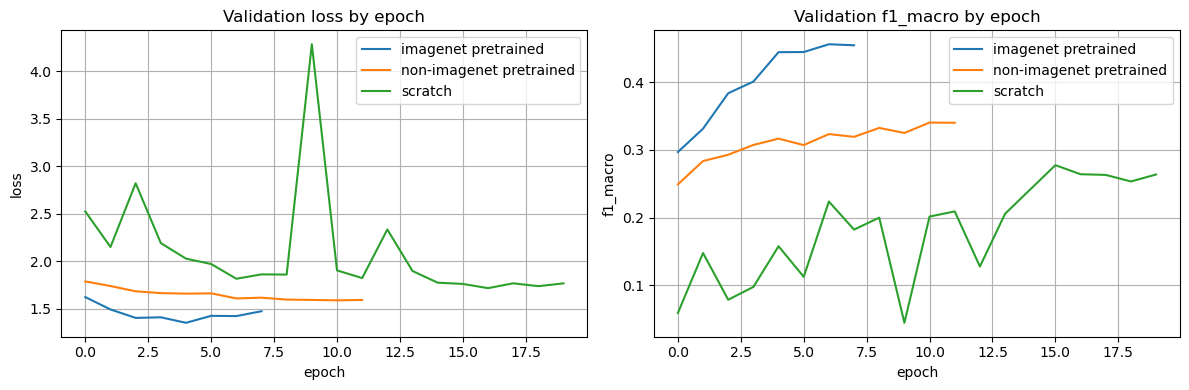

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_imagenet['val_loss'], label='imagenet pretrained')
plt.plot(hist_non_imagenet['val_loss'], label='non-imagenet pretrained')
plt.plot(hist_scratch['val_loss'], label='scratch')
plt.title('Validation loss by epoch')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(hist_imagenet['val_f1'], label='imagenet pretrained')
plt.plot(hist_non_imagenet['val_f1'], label='non-imagenet pretrained')
plt.plot(hist_scratch['val_f1'], label='scratch')
plt.title('Validation f1_macro by epoch')
plt.xlabel('epoch')
plt.ylabel('f1_macro')
plt.legend()
plt.grid(True)
plt.tight_layout()


In [ ]:
results = {
    'imagenet_pretrained': test_imagenet['f1_macro'],
    'non_imagenet_pretrained': test_non_imagenet['f1_macro'],
    'scratch_custom': test_scratch['f1_macro'],
}
best_name = max(results, key=results.get)
best_f1 = results[best_name]
print('f1_macro results:', results)
print('best model:', best_name, '| best f1_macro:', round(best_f1, 4))
print('interpretation: f1_macro close to 1 means balanced high quality across all color classes; low value means model fails on part of classes.')


f1_macro results: {'imagenet_pretrained': 0.4563, 'non_imagenet_pretrained': 0.3405, 'scratch_custom': 0.2775}
best model: imagenet_pretrained | best f1_macro: 0.4563
interpretation: f1_macro close to 1 means balanced high quality across all color classes; low value means model fails on part of classes.
